In [1]:
import pandas as pd
import numpy as np

file_path = r"C:\Users\Dell\Desktop\E-commerce-Customer-Sales-Intelligence\data\online_retail_II.csv"

df = pd.read_csv(file_path, encoding="latin1")

print(df.shape)
print(df.columns.tolist())

(525461, 9)
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'price', 'Customer ID', 'Country', 'Revenue=Quantity_cell*UnitPrice_cell']


In [2]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'price', 'Customer ID', 'Country', 'Revenue=Quantity_cell*UnitPrice_cell']


In [3]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'price', 'Customer ID', 'Country', 'Revenue=Quantity_cell*UnitPrice_cell']


In [4]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'price', 'Customer_ID', 'Country', 'Revenue=Quantity_cell*UnitPrice_cell']


In [5]:
print(df.dtypes)

Invoice                                  object
StockCode                                object
Description                              object
Quantity                                  int64
InvoiceDate                              object
price                                   float64
Customer_ID                             float64
Country                                  object
Revenue=Quantity_cell*UnitPrice_cell    float64
dtype: object


In [6]:
print(df[["Quantity", "price", "InvoiceDate", "Customer_ID"]].head())

   Quantity  price       InvoiceDate  Customer_ID
0        12   6.95  01-12-2009 07:45      13085.0
1        12   6.75  01-12-2009 07:45      13085.0
2        12   6.75  01-12-2009 07:45      13085.0
3        48   2.10  01-12-2009 07:45      13085.0
4        24   1.25  01-12-2009 07:45      13085.0


In [7]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'price', 'Customer_ID', 'Country', 'Revenue=Quantity_cell*UnitPrice_cell']


In [8]:
# Standardize column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Check the actual columns
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'price', 'Customer_ID', 'Country', 'Revenue=Quantity_cell*UnitPrice_cell']


In [9]:
customer_df = df[df["Customer_ID"].notna()].copy()

print("Customer records:", len(customer_df))
print("Unique customers:", customer_df["Customer_ID"].nunique())

Customer records: 417534
Unique customers: 4383


In [10]:
customer_df.to_csv("../data/customer_analysis.csv", index=False)

print("Customer dataset saved!")

Customer dataset saved!


In [11]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'price', 'Customer_ID', 'Country', 'Revenue=Quantity_cell*UnitPrice_cell']


In [12]:
# Reset column names to simple names
df.columns = [
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "price",
    "Customer_ID",
    "Country",
    "Revenue"
]

print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'price', 'Customer_ID', 'Country', 'Revenue']


In [13]:
# Make sure required columns have the correct data types
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["Revenue"] = df["Quantity"] * df["price"]

# Customer-level dataset
customer_df = df.dropna(subset=["Customer_ID"]).copy()

print("Customer records:", len(customer_df))
print("Unique customers:", customer_df["Customer_ID"].nunique())

Customer records: 417534
Unique customers: 4383


In [14]:
analysis_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = customer_df.groupby("Customer_ID").agg(
    Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

print("RFM customers:", len(rfm))
rfm.head()

RFM customers: 4383


,Customer_ID,Recency,Frequency,Monetary
0,12346.0,246.0,15,-64.68
1,12347.0,153.0,2,1323.32
2,12348.0,NaN,1,222.16
3,12349.0,609.0,4,2646.99
4,12351.0,NaN,1,300.93


In [15]:
# create RFM Score customers
rfm["R_score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["RFM_Score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

rfm.head()

,Customer_ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346.0,246.0,15,-64.68,2,5,1,251
1,12347.0,153.0,2,1323.32,3,2,4,324
2,12348.0,NaN,1,222.16,NaN,1,1,nan11
3,12349.0,609.0,4,2646.99,1,3,5,135
4,12351.0,NaN,1,300.93,NaN,1,2,nan12


In [16]:
def segment_customer(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Champions"
    elif row["R_score"] >= 3 and row["F_score"] >= 3:
        return "Loyal Customers"
    elif row["R_score"] >= 4 and row["F_score"] <= 2:
        return "Potential Loyalists"
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"
    else:
        return "Dormant"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

print(rfm["Segment"].value_counts())

Segment
Dormant                1893
Loyal Customers         805
At Risk                 742
Champions               741
Potential Loyalists     202
Name: count, dtype: int64


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Clean RFM values before K-Means
rfm_model = rfm[["Customer_ID", "Recency", "Frequency", "Monetary"]].copy()

# Convert RFM columns to numbers
rfm_model["Recency"] = pd.to_numeric(rfm_model["Recency"], errors="coerce")
rfm_model["Frequency"] = pd.to_numeric(rfm_model["Frequency"], errors="coerce")
rfm_model["Monetary"] = pd.to_numeric(rfm_model["Monetary"], errors="coerce")

# Remove invalid values
rfm_model = rfm_model.replace([np.inf, -np.inf], np.nan)
rfm_model = rfm_model.dropna(subset=["Recency", "Frequency", "Monetary"])

print("Customers available for K-Means:", len(rfm_model))

# Scale
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(
    rfm_model[["Recency", "Frequency", "Monetary"]]
)

# K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_model["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("\nCluster counts:")
print(rfm_model["Cluster"].value_counts())

Customers available for K-Means: 3117

Cluster counts:
Cluster
1    2165
0     893
3      54
2       5
Name: count, dtype: int64


In [23]:
#Understand the clusters
cluster_summary = rfm_model.groupby("Cluster").agg(
    Customers=("Customer_ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,893,335.27,3.26,962.30
1,2165,78.84,6.72,2022.02
2,5,5.00,139.00,206931.73
3,54,13.00,59.61,27549.87


In [24]:
cluster_summary.sort_values("Avg_Monetary", ascending=False)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
2,5,5.00,139.00,206931.73
3,54,13.00,59.61,27549.87
1,2165,78.84,6.72,2022.02
0,893,335.27,3.26,962.30


In [25]:
#Automatically label the 4 clusters
cluster_summary = rfm_model.groupby("Cluster").agg(
    Customers=("Customer_ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

print(cluster_summary)

         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                     
0              893       335.27           3.26        962.30
1             2165        78.84           6.72       2022.02
2                5         5.00         139.00     206931.73
3               54        13.00          59.61      27549.87


In [26]:
cluster_summary = rfm_model.groupby("Cluster").agg(
    Customers=("Customer_ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,893,335.27,3.26,962.30
1,2165,78.84,6.72,2022.02
2,5,5.00,139.00,206931.73
3,54,13.00,59.61,27549.87


In [27]:
#Save your K-Means results
rfm_model.to_csv(
    "../outputs/rfm_kmeans_customers.csv",
    index=False
)

print("K-Means customer file saved successfully.")

K-Means customer file saved successfully.


In [28]:
#Start Churn Analysis
#We'll classify a customer as churned if they haven't purchased for 90+ days relative to the latest transaction date.
churn_df = rfm_model.copy()

churn_df["Churn"] = (
    churn_df["Recency"] >= 90
).astype(int)

print(churn_df["Churn"].value_counts())

Churn
1    1901
0    1216
Name: count, dtype: int64


In [29]:
#Prepare ML features
X = churn_df[["Recency", "Frequency", "Monetary"]]

y = churn_df["Churn"]

print("Features:", X.shape)
print("Target:", y.value_counts().to_dict())

Features: (3117, 3)
Target: {1: 1901, 0: 1216}


In [30]:
#Now we build the churn model.
#One important correction before training: because our Churn label was created directly from Recency, we must NOT use Recency as a model feature. 
# Otherwise we'd leak the answer into the model.
#Train/test split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Do NOT include Recency because Churn was defined from Recency
X = churn_df[["Frequency", "Monetary"]]
y = churn_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (2493, 2)
Testing: (624, 2)


In [31]:
#Logistic Regression
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7099358974358975
Precision: 0.7
Recall: 0.9186351706036745
F1 Score: 0.7945516458569807
ROC-AUC: 0.7055884989684931


In [32]:
#Detailed results
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.38      0.51       243
           1       0.70      0.92      0.79       381

    accuracy                           0.71       624
   macro avg       0.72      0.65      0.65       624
weighted avg       0.72      0.71      0.68       624



In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.5721153846153846
Precision: 0.6565934065934066
Recall: 0.6272965879265092
F1 Score: 0.6416107382550336
ROC-AUC: 0.5903297581629456


In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.5721153846153846
Precision: 0.6565934065934066
Recall: 0.6272965879265092
F1 Score: 0.6416107382550336
ROC-AUC: 0.5903297581629456


In [ ]:
#Compare models
print("Logistic Regression F1:", f1_score(y_test, y_pred))
print("Random Forest F1:", f1_score(y_test, rf_pred))

Logistic Regression F1: 0.7945516458569807
Random Forest F1: 0.6416107382550336


In [37]:
#Random Forest churn model
from sklearn.ensemble import RandomForestClassifier

rf_model_churn = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model_churn.fit(X_train, y_train)

rf_pred = rf_model_churn.predict(X_test)
rf_prob = rf_model_churn.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("---------------------")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Random Forest Results
---------------------
Accuracy: 0.5721153846153846
Precision: 0.6565934065934066
Recall: 0.6272965879265092
F1 Score: 0.6416107382550336
ROC-AUC: 0.5903297581629456


In [38]:
#Compare feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model_churn.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
1,Monetary,0.869904
0,Frequency,0.130096


In [39]:
#Create customer first-purchase month
cohort_df = customer_df.copy()

cohort_df["InvoiceMonth"] = (
    cohort_df["InvoiceDate"]
    .dt.to_period("M")
)

cohort_df["CohortMonth"] = (
    cohort_df.groupby("Customer_ID")["InvoiceMonth"]
    .transform("min")
)

cohort_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,price,Customer_ID,Country,Revenue,InvoiceMonth,CohortMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-01-12 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-01,2009-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-01-12 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-01,2009-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-01-12 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-01,2009-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-01-12 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-01,2009-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-01-12 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-01,2009-01


In [40]:
#Calculate cohort index
cohort_df["CohortIndex"] = (
    (cohort_df["InvoiceMonth"].dt.year -
     cohort_df["CohortMonth"].dt.year) * 12
    +
    (cohort_df["InvoiceMonth"].dt.month -
     cohort_df["CohortMonth"].dt.month)
    + 1
)

cohort_df[[
    "Customer_ID",
    "InvoiceMonth",
    "CohortMonth",
    "CohortIndex"
]].head()

,Customer_ID,InvoiceMonth,CohortMonth,CohortIndex
0,13085.0,2009-01,2009-01,1
1,13085.0,2009-01,2009-01,1
2,13085.0,2009-01,2009-01,1
3,13085.0,2009-01,2009-01,1
4,13085.0,2009-01,2009-01,1


In [41]:
#Build retention table
cohort_counts = (
    cohort_df
    .groupby(["CohortMonth", "CohortIndex"])["Customer_ID"]
    .nunique()
    .reset_index()
)

cohort_table = cohort_counts.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="Customer_ID"
)

cohort_table

CohortIndex,-24144,-24143,-24142,-24141,-24140,-24139,-24138,-24137,-24136,-24135,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,24.0,29.0,31.0,29.0,29.0,35.0,34.0,28.0,31.0,26.0
2009-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,18.0,27.0,20.0,25.0,27.0,24.0,17.0,26.0,24.0,NaN
2009-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,24.0,19.0,19.0,26.0,23.0,15.0,20.0,31.0,NaN,NaN
2009-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,18.0,22.0,20.0,18.0,13.0,12.0,15.0,NaN,NaN,NaN
2009-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,5.0,7.0,5.0,3.0,4.0,NaN,NaN,NaN,NaN
2009-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.0,13.0,14.0,7.0,9.0,NaN,NaN,NaN,NaN,NaN
2009-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.0,11.0,14.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN
2009-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.0,15.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
#Convert to retention %
retention = cohort_table.divide(
    cohort_table[1],
    axis=0
) * 100

retention.round(1)

CohortIndex,-24144,-24143,-24142,-24141,-24140,-24139,-24138,-24137,-24136,-24135,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.5,24.8,26.5,24.8,24.8,29.9,29.1,23.9,26.5,22.2
2009-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,18.9,28.4,21.1,26.3,28.4,25.3,17.9,27.4,25.3,NaN
2009-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23.5,18.6,18.6,25.5,22.5,14.7,19.6,30.4,NaN,NaN
2009-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,25.0,30.6,27.8,25.0,18.1,16.7,20.8,NaN,NaN,NaN
2009-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.0,20.0,28.0,20.0,12.0,16.0,NaN,NaN,NaN,NaN
2009-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.7,22.4,24.1,12.1,15.5,NaN,NaN,NaN,NaN,NaN
2009-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17.9,16.4,20.9,13.4,NaN,NaN,NaN,NaN,NaN,NaN
2009-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.0,15.8,14.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.0,18.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


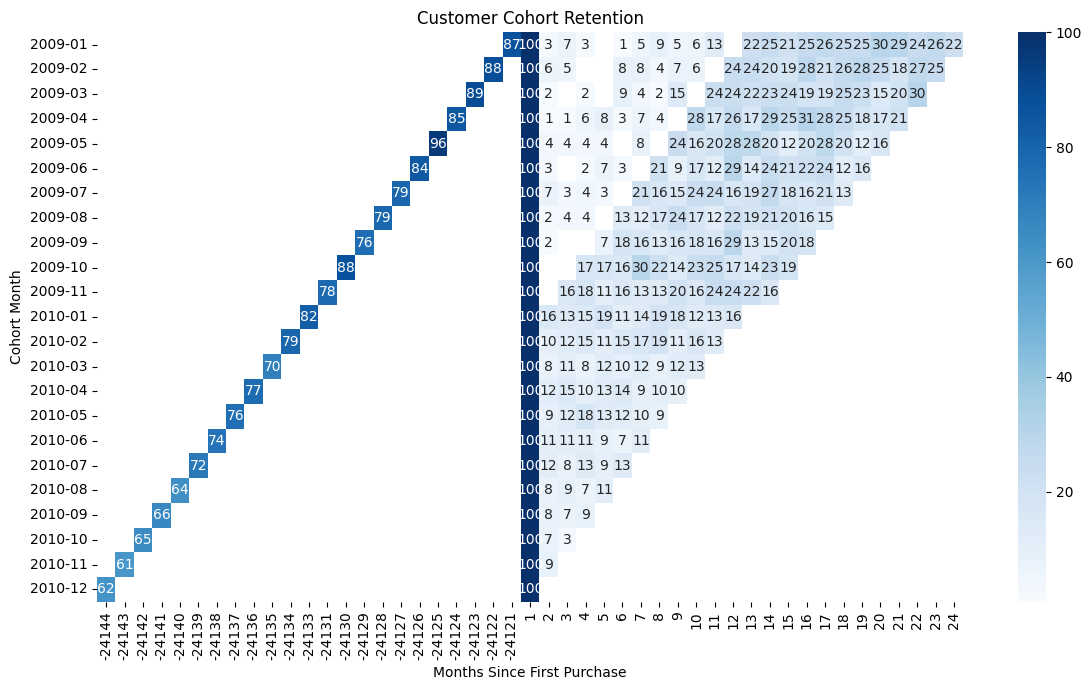

In [44]:
#Retention heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Customer Cohort Retention")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

In [45]:
#Calculate customer metrics
#We'll use a simple historical CLV - Customer Lifetime Value approach that's easy to explain in an interview.
#Calculate customer metrics
clv_df = customer_df.groupby("Customer_ID").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Orders=("Invoice", "nunique"),
    Total_Quantity=("Quantity", "sum"),
    First_Purchase=("InvoiceDate", "min"),
    Last_Purchase=("InvoiceDate", "max")
).reset_index()

clv_df["Customer_Lifespan_Days"] = (
    clv_df["Last_Purchase"] -
    clv_df["First_Purchase"]
).dt.days

clv_df.head()

,Customer_ID,Total_Revenue,Total_Orders,Total_Quantity,First_Purchase,Last_Purchase,Customer_Lifespan_Days
0,12346.0,-64.68,15,52,2010-02-03 13:08:00,2010-04-10 16:33:00,66.0
1,12347.0,1323.32,2,828,2010-07-12 14:57:00,2010-07-12 14:57:00,0.0
2,12348.0,222.16,1,373,NaT,NaT,NaN
3,12349.0,2646.99,4,988,2009-04-12 12:49:00,2009-04-12 12:49:00,0.0
4,12351.0,300.93,1,261,NaT,NaT,NaN


In [46]:
#Average order value
clv_df["Average_Order_Value"] = (
    clv_df["Total_Revenue"] /
    clv_df["Total_Orders"].replace(0, np.nan)
)

In [47]:
#Simple historical CLV
#Historical CLV = Total Revenue generated by the customer
clv_df["CLV"] = clv_df["Total_Revenue"]

clv_df.sort_values(
    "CLV",
    ascending=False
).head(10)

,Customer_ID,Total_Revenue,Total_Orders,Total_Quantity,First_Purchase,Last_Purchase,Customer_Lifespan_Days,Average_Order_Value,CLV
4254,18102.0,341776.73,95,122988,2009-01-12 09:24:00,2010-12-04 13:11:00,691.0,3597.649789,341776.73
1662,14646.0,243853.05,87,168501,2009-02-12 16:52:00,2010-12-03 10:41:00,658.0,2802.908621,243853.05
1291,14156.0,183180.55,138,106885,2009-01-12 12:30:00,2010-12-09 12:31:00,696.0,1327.395290,183180.55
1869,14911.0,137675.91,270,66561,2009-01-12 11:41:00,2010-12-11 13:18:00,698.0,509.910778,137675.91
957,13694.0,128172.42,105,123639,2009-04-12 15:26:00,2010-12-08 10:02:00,604.0,1220.689714,128172.42
3807,17511.0,83760.60,42,54901,2009-02-12 10:52:00,2010-12-05 10:56:00,661.0,1994.300000,83760.60
1983,15061.0,82162.74,90,51395,2009-01-12 12:18:00,2010-12-11 14:39:00,698.0,912.919333,82162.74
3178,16684.0,75610.17,34,51705,2009-07-12 12:56:00,2010-11-06 11:38:00,481.0,2223.828529,75610.17
511,13089.0,55828.31,132,28456,2009-02-12 15:44:00,2010-12-08 08:56:00,663.0,422.941742,55828.31
3228,16754.0,54558.18,35,54190,2010-02-12 17:38:00,2010-12-04 07:07:00,294.0,1558.805143,54558.18


In [48]:
#CLV segments
clv_df["CLV_Segment"] = pd.qcut(
    clv_df["CLV"].rank(method="first"),
    4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "VIP"
    ]
)

clv_df["CLV_Segment"].value_counts()

CLV_Segment
Low Value       1096
Medium Value    1096
VIP             1096
High Value      1095
Name: count, dtype: int64

In [49]:
#Save it
clv_df.to_csv(
    "../outputs/customer_clv.csv",
    index=False
)

print("CLV analysis saved.")

CLV analysis saved.
